# Problem Set 1 — ¿Qué distingue a un género musical?

**S100 · Introducción a la Ciencia de Datos** · Maestría en Analítica de Datos, UTP
**Prof. Gabriel Soto, M.Sc.** · II Semestre 2026

**Modalidad:** individual · **Datos:** `spotify_songs.csv` (32,833 canciones)

---

## El caso

Una plataforma de streaming quiere entender **en qué se diferencian los géneros musicales**
según las características de audio de sus canciones. Te pasan la tabla completa y cinco
preguntas que van de lo general a lo específico.

Los cinco ejercicios están **encadenados**: cada uno usa resultados del anterior. Resuélvelos
en orden y no borres las variables que vayas creando.

---

## Instrucciones de entrega

**1 · Trabaja sobre este cuaderno.** Escribe tu código en las celdas marcadas y tus respuestas
escritas en las celdas de texto que dicen *Tu respuesta*. El cuaderno debe **correr de principio
a fin sin errores** (Kernel → Restart & Run All antes de entregar).

**2 · Sube el cuaderno a tu repositorio de GitHub.**

- Crea (o usa) un repositorio para el curso, por ejemplo `S100-analitica-datos`.
- Súbelo con el nombre `S100_PS1_TuApellido.ipynb`.
- El repositorio debe ser **público** (o darme acceso). Si no puedo abrirlo, no puedo calificarlo.
- El historial de commits debe mostrar tu trabajo: haz varios commits, no uno solo al final.

**3 · Envía por correo ÚNICAMENTE el enlace a GitHub.**

- Correo: **gabriel.soto@utp.ac.pa**
- Asunto: `S100 - Problem Set 1 - TuNombre`
- En el cuerpo va **solo el enlace** al repositorio (o al cuaderno dentro del repositorio).
- **No adjuntes archivos.** Los correos con el cuaderno adjunto y sin enlace no se califican.

**4 · Registra tu enlace en la lista del curso.**

- Abre el archivo **`S100 Lista Estudiantes Provisional`**, ubicado en el **SharePoint del curso**,
  carpeta **`01_administracion`**.
- Agrega el enlace de tu repositorio de GitHub **en la fila que corresponde a tu nombre**.
- Este paso es parte de la entrega: sin el enlace en la lista, la entrega se considera incompleta.

> **Sobre el uso de IA.** Está permitido, con una condición: que puedas explicar lo que
> entregaste. En la última celda del cuaderno indica en qué ejercicios la usaste y qué hace ese
> código. No hay penalización por usarla; sí la hay por entregar código que no sabes leer.

## Calificación

| Ejercicio | Qué se evalúa | Puntos |
|---|---|---|
| 1 | Exploración inicial correcta y completa | 15 |
| 2 | Resumen numérico + histograma bien etiquetado | 15 |
| 3 | Comparación por género + gráfico que se entiende solo | 20 |
| 4 | Matriz de correlación, identificación de pares, interpretación | 25 |
| 5 | Correlación por grupo, estandarización y conclusión escrita | 25 |

Los gráficos sin **título** y sin **etiquetas de eje con unidad** pierden puntos, siempre.


**Estudiante:** Karina Correa  
**Entrega:** `S100_PS1_Correa.ipynb`  
**Dataset:** `spotify_songs.csv` — 32,833 canciones, 6 géneros


---
## Paso 0 · Preparación

Ejecuta esta celda. No hay que escribir nada aquí.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AZUL = "#13294B"
plt.rcParams.update({"figure.figsize": (8, 4.2), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "axes.axisbelow": True,
                     "grid.color": "#D3D8E0", "axes.titleweight": "bold", "font.size": 10})

df = pd.read_csv("spotify_songs.csv")

# La duración viene en milisegundos: la pasamos a minutos, que sí se puede interpretar.
df["duration_min"] = df["duration_ms"] / 60000

# Las 10 variables de audio con las que vamos a trabajar todo el problem set.
audio = ["danceability", "energy", "loudness", "speechiness", "acousticness",
         "instrumentalness", "liveness", "valence", "tempo", "duration_min"]

print("Filas y columnas:", df.shape)

Filas y columnas: (32833, 24)


### Diccionario de las columnas que vas a usar

| Columna | Qué es |
|---|---|
| `track_name`, `track_artist` | Nombre de la canción y del artista |
| `track_popularity` | Popularidad de 0 a 100 |
| `playlist_genre` | Género: pop, rap, rock, latin, r&b, edm |
| `danceability`, `energy`, `valence`, `acousticness`, `instrumentalness`, `liveness`, `speechiness` | Índices de 0 a 1 |
| `loudness` | Volumen medio en decibeles (negativo) |
| `tempo` | Pulsos por minuto (BPM) |
| `duration_min` | Duración en minutos (la creamos arriba) |


---
# Ejercicio 1 · Conocer los datos antes de calcular nada
**Dificultad: baja** · 15 puntos

Antes de responder cualquier pregunta hay que saber qué hay en la tabla. Haz estas cuatro cosas:

**a)** Muestra las **primeras filas** de `df`.

**b)** Saca el **resumen estadístico** de las columnas numéricas.

**c)** Cuenta **cuántas canciones hay de cada género** (`playlist_genre`).

**d)** Cuenta **cuántos valores faltan** en cada columna.

> 💡 **Pistas.** `df.head()` · `df.describe()` · `df["columna"].value_counts()` · `df.isna().sum()`
> Para ver solo las columnas donde sí falta algo: guarda el resultado en una variable `faltan` y
> filtra con `faltan[faltan > 0]`.

In [2]:
# a) Primeras filas
print("a) PRIMERAS FILAS")
display(df.head())

# b) Resumen estadistico
print("\nb) RESUMEN ESTADISTICO DE LAS COLUMNAS NUMERICAS")
display(df.describe().T)

# c) Canciones por genero
print("\nc) CANCIONES POR GENERO")
conteo_genero = df["playlist_genre"].value_counts()
print(conteo_genero)
print("\nGenero mas grande / genero mas pequeno =",
      round(conteo_genero.max() / conteo_genero.min(), 2))

# d) Valores faltantes
print("\nd) VALORES FALTANTES (solo columnas donde si falta algo)")
faltan = df.isna().sum()
print(faltan[faltan > 0])
print("\nFilas con algun dato faltante:", df.isna().any(axis=1).sum(),
      "de", len(df), "(", round(100 * df.isna().any(axis=1).sum() / len(df), 3), "% )")
print("Faltantes en las 10 variables de audio:", int(df[audio].isna().sum().sum()))

a) PRIMERAS FILAS


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,duration_min
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754,3.245900
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600,2.710000
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616,2.943600
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093,2.818217
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052,3.150867



b) RESUMEN ESTADISTICO DE LAS COLUMNAS NUMERICAS


,count,mean,std,min,25%,50%,75%,max
track_popularity,32833.0,42.477081,24.984074,0.000000,24.000000,45.000000,62.000000,100.000000
danceability,32833.0,0.654850,0.145085,0.000000,0.563000,0.672000,0.761000,0.983000
energy,32833.0,0.698619,0.180910,0.000175,0.581000,0.721000,0.840000,1.000000
key,32833.0,5.374471,3.611657,0.000000,2.000000,6.000000,9.000000,11.000000
loudness,32833.0,-6.719499,2.988436,-46.448000,-8.171000,-6.166000,-4.645000,1.275000
mode,32833.0,0.565711,0.495671,0.000000,0.000000,1.000000,1.000000,1.000000
speechiness,32833.0,0.107068,0.101314,0.000000,0.041000,0.062500,0.132000,0.918000
acousticness,32833.0,0.175334,0.219633,0.000000,0.015100,0.080400,0.255000,0.994000
instrumentalness,32833.0,0.084747,0.224230,0.000000,0.000000,0.000016,0.004830,0.994000
liveness,32833.0,0.190176,0.154317,0.000000,0.092700,0.127000,0.248000,0.996000



c) CANCIONES POR GENERO
playlist_genre
edm      6043
rap      5746
pop      5507
r&b      5431
latin    5155
rock     4951
Name: count, dtype: int64

Genero mas grande / genero mas pequeno = 1.22

d) VALORES FALTANTES (solo columnas donde si falta algo)
track_name          5
track_artist        5
track_album_name    5
dtype: int64

Filas con algun dato faltante: 5 de 32833 ( 0.015 % )
Faltantes en las 10 variables de audio: 0


### 📝 Tu respuesta — Ejercicio 1

**1.** ¿Los seis géneros tienen más o menos la misma cantidad de canciones, o hay alguno
   muy por encima o por debajo? ¿Por qué importa eso antes de comparar promedios entre géneros?

Los seis géneros tienen cantidades bastante parecidas de canciones. El que tiene más es EDM, con
**6,043 canciones**, y el que tiene menos es rock, con **4,951**. Los demás están entre esos valores: rap
(5,746), pop (5,507), R&B (5,431) y latin (5,155).

La diferencia entre el género con más canciones y el que tiene menos es de aproximadamente **22%**, por
lo que no hay una diferencia demasiado grande entre los grupos.

Esto es importante porque, si un género tuviera muchas más canciones que otro, su promedio tendría
más peso al analizar todos los datos juntos. Además, cuando un grupo tiene pocos datos, su promedio
puede variar más fácilmente por algunos valores extremos. Como en este caso las cantidades son
similares, la comparación entre los géneros es más equilibrada.

**2.** Mira la fila `min` y la fila `max` de `duration_min` en el `describe()`. ¿Hay algún valor
   que te haga sospechar de un error de captura? Explica en una frase.

Sí. El valor mínimo de **0.067 minutos**, que equivale aproximadamente a 4 segundos, me parece
sospechoso porque es demasiado corto para una canción completa. Podría tratarse de un audio cortado,
un fragmento o algún error en los datos.

En cambio, el máximo de 8.63 minutos sí puede corresponder a una canción larga, por lo que no me
parece tan preocupante.

---
# Ejercicio 2 · Resumir una variable
**Dificultad: baja** · 15 puntos

Del Ejercicio 1 ya sabes qué contiene la tabla. Ahora nos concentramos en **una sola variable:
`energy`**, que va a ser el hilo conductor del resto del problem set.

**a)** Calcula de `energy`: **media**, **mediana**, **desviación estándar** y **rango**
(el rango es el máximo menos el mínimo).

**b)** Haz un **histograma** de `energy` con 30 barras. Debe llevar **título** y **etiquetas de eje**.

**c)** Calcula el `skew()` de `energy`.

> 💡 **Pistas.** Los resúmenes son métodos: `df["energy"].mean()`, `.median()`, `.std()`,
> `.max()`, `.min()`, `.skew()`.
> Para el histograma: `plt.hist(df["energy"], bins=30, color=AZUL, edgecolor="white")` y luego
> `plt.xlabel(...)`, `plt.ylabel(...)`, `plt.title(...)`, `plt.show()`.
> Recuerda: skew cerca de 0 = simétrica; positivo = cola a la derecha; negativo = cola a la izquierda.

RESUMEN DE energy (indice de 0 a 1, sin unidad)
  Media               : 0.6986
  Mediana             : 0.7210
  Desviacion estandar : 0.1809
  Rango               : 0.9998   (min = 0.0002, max = 1.0000)


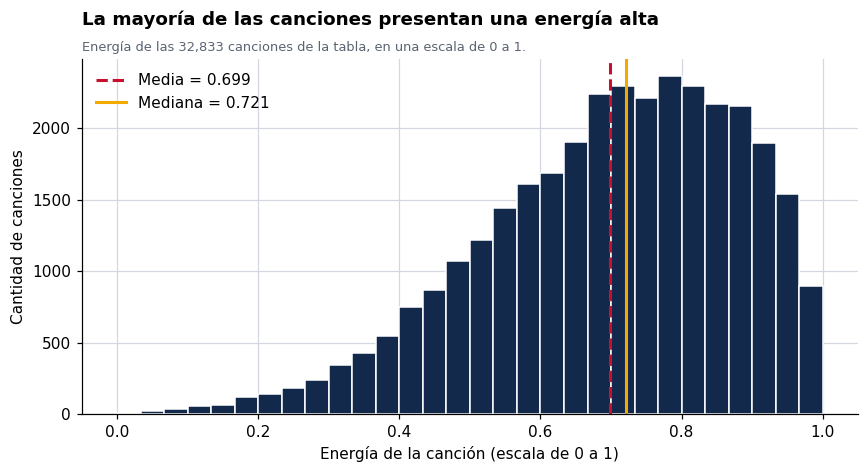


Asimetria (skew) de energy : -0.6363
Signo negativo -> la cola larga esta del lado IZQUIERDO (valores bajos).
Comprobacion: media - mediana = -0.0224  (negativo, consistente con el skew)


In [3]:
energy = df["energy"]

# a) Media, mediana, desviacion estandar y rango de energy
media_e   = energy.mean()
mediana_e = energy.median()
desv_e    = energy.std()
rango_e   = energy.max() - energy.min()

print("RESUMEN DE energy (indice de 0 a 1, sin unidad)")
print(f"  Media               : {media_e:.4f}")
print(f"  Mediana             : {mediana_e:.4f}")
print(f"  Desviacion estandar : {desv_e:.4f}")
print(f"  Rango               : {rango_e:.4f}   (min = {energy.min():.4f}, max = {energy.max():.4f})")

# b) Histograma
plt.figure(figsize=(8, 4.4))
plt.hist(energy, bins=30, color=AZUL, edgecolor="white")
plt.axvline(media_e,   color="#C8102E", lw=2, ls="--", label=f"Media = {media_e:.3f}")
plt.axvline(mediana_e, color="#F2A900", lw=2, ls="-",  label=f"Mediana = {mediana_e:.3f}")
plt.xlabel("Energía de la canción (escala de 0 a 1)")
plt.ylabel("Cantidad de canciones")
ax = plt.gca()
ax.set_title("La mayoría de las canciones presentan una energía alta",
             fontsize=12, fontweight="bold", loc="left", pad=22)
ax.text(0, 1.015,
        "Energía de las 32,833 canciones de la tabla, en una escala de 0 a 1.",
        transform=ax.transAxes, fontsize=8.5, color="#5A6472", va="bottom")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# c) Asimetria
skew_e = energy.skew()
print(f"\nAsimetria (skew) de energy : {skew_e:.4f}")
print("Signo negativo -> la cola larga esta del lado IZQUIERDO (valores bajos).")
print(f"Comprobacion: media - mediana = {media_e - mediana_e:.4f}  (negativo, consistente con el skew)")

### 📝 Tu respuesta — Ejercicio 2

**1.** Escribe los cuatro números de (a) en una frase.

La media de `energy` es **0.699**, la mediana es **0.721**, la desviación estándar es **0.181** y el rango es **0.9998**, con un valor mínimo de 0.000175 y un máximo de 1.000.

Esto indica que la mayoría de las canciones de la tabla tienen un nivel de energía alto, alrededor
de 0.70 en una escala de 0 a 1. La desviación estándar de 0.181 significa que la mayor parte de los
valores se ubica aproximadamente entre 0.52 y 0.88. El rango cubre casi toda la escala, por lo que
la tabla incluye desde canciones muy tranquilas hasta canciones muy intensas.

**2.** ¿La media quedó por encima o por debajo de la mediana? ¿Hacia qué lado está la cola?
   ¿Coincide eso con el signo del `skew()` y con lo que ves en el histograma?

La media (0.699) quedó **por debajo** de la mediana (0.721), con una diferencia de −0.022. Esto indica
que la cola larga de la distribución está del lado **izquierdo**, es decir, hacia los valores bajos de
`energy`.

El resultado del `skew()` fue **−0.636** y el signo negativo confirma lo mismo: la cola se extiende hacia
la izquierda.

El histograma también coincide. La mayor cantidad de canciones se concentra entre 0.6 y 0.95, con el
punto más alto cerca de 0.8, y las barras van disminuyendo de forma gradual hacia la izquierda hasta
llegar a valores cercanos a cero. Ese grupo reducido de canciones con energía muy baja es lo que hace
que la media quede por debajo de la mediana, ya que la mediana solo depende de la posición central de
los datos y los valores extremos no la afectan.

---
# Ejercicio 3 · ¿En qué se diferencian los géneros?
**Dificultad: baja** · 20 puntos

Ya sabes cómo se reparte `energy` en toda la tabla. La pregunta ahora es si **esa repartición es
la misma dentro de cada género**.

**a)** Calcula la **media** y la **desviación estándar** de `energy` **por género**, en una sola tabla.
Ordénala de mayor a menor por la media y guárdala en una variable llamada `energia_genero`
(la vas a volver a usar en el Ejercicio 5).

**b)** Haz un **gráfico de barras horizontales** con la media de `energy` por género.
Ordenado por valor, con título y etiqueta de eje.

**c)** Haz un **boxplot** de `energy` por género.

> 💡 **Pistas.**
> `df.groupby("playlist_genre")["energy"].agg(["mean", "std"])` da las dos columnas de una vez;
> después `.sort_values("mean", ascending=False)`.
> Barras horizontales: `plt.barh(serie.index, serie.values, color=AZUL)` — ordena la serie de
> **menor a mayor** para que la barra más larga quede arriba.
> Boxplot: `df.boxplot(column="energy", by="playlist_genre")`, o armando la lista de grupos
> como hicimos en el laboratorio de la Clase 3.
>
> ⚠️ "Más enérgico" y "más disperso" son preguntas distintas: la primera la contesta la media,
> la segunda la desviación estándar. No asumas que van juntas.

ENERGY POR GENERO (media y desviacion estandar, indice 0-1)
                  mean     std
playlist_genre                
edm             0.8025  0.1394
rock            0.7328  0.1945
latin           0.7083  0.1523
pop             0.7010  0.1711
rap             0.6507  0.1703
r&b             0.5909  0.1794


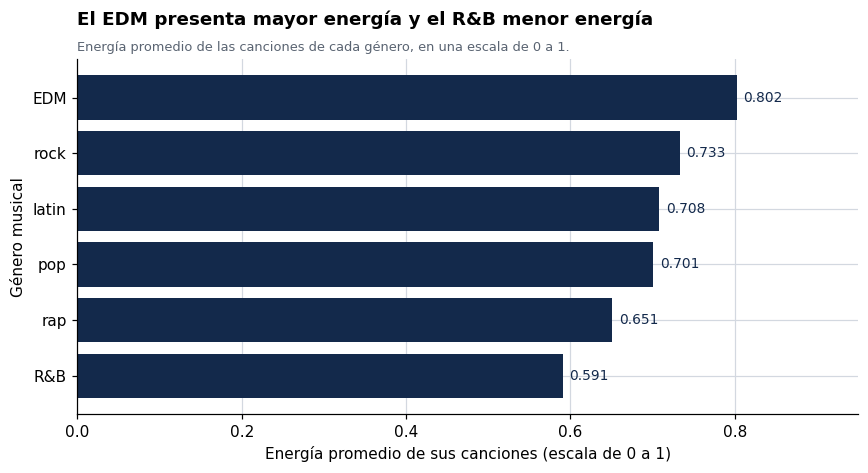

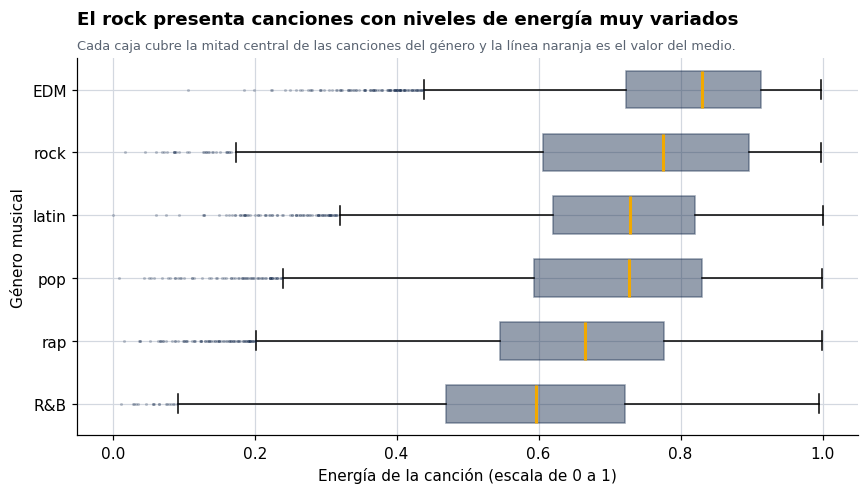


Ordenado por DISPERSION (desviacion estandar), de mayor a menor:
playlist_genre
rock     0.1945
r&b      0.1794
pop      0.1711
rap      0.1703
latin    0.1523
edm      0.1394
Name: std, dtype: float64


In [4]:
# a) Media y desviacion de energy por genero
energia_genero = (df.groupby("playlist_genre")["energy"]
                    .agg(["mean", "std"])
                    .sort_values("mean", ascending=False))
print("ENERGY POR GENERO (media y desviacion estandar, indice 0-1)")
print(energia_genero.round(4))

# Nombres de genero como se escriben normalmente (los uso en los dos graficos)
NOMBRES = {"edm": "EDM", "r&b": "R&B", "rock": "rock",
           "pop": "pop", "latin": "latin", "rap": "rap"}

# b) Grafico de barras horizontales
serie = energia_genero["mean"].sort_values()          # menor a mayor -> la mas larga queda arriba
plt.figure(figsize=(8, 4.4))
plt.barh([NOMBRES[g] for g in serie.index], serie.values, color=AZUL)
for y, v in zip([NOMBRES[g] for g in serie.index], serie.values):
    plt.text(v + 0.008, y, f"{v:.3f}", va="center", fontsize=9, color=AZUL)
plt.xlim(0, 0.95)
plt.xlabel("Energía promedio de sus canciones (escala de 0 a 1)")
plt.ylabel("Género musical")
ax = plt.gca()
ax.set_title("El EDM presenta mayor energía y el R&B menor energía",
             fontsize=12, fontweight="bold", loc="left", pad=22)
ax.text(0, 1.015,
        "Energía promedio de las canciones de cada género, en una escala de 0 a 1.",
        transform=ax.transAxes, fontsize=8.5, color="#5A6472", va="bottom")
plt.tight_layout()
plt.show()

# c) Boxplot
orden = energia_genero.index.tolist()[::-1]           # de menor a mayor media
grupos = [df.loc[df["playlist_genre"] == g, "energy"].values for g in orden]

plt.figure(figsize=(8, 4.6))
bp = plt.boxplot(grupos, vert=False, patch_artist=True, widths=0.6,
                 medianprops=dict(color="#F2A900", lw=2),
                 flierprops=dict(marker="o", markersize=2, alpha=0.25,
                                 markerfacecolor=AZUL, markeredgecolor="none"))
for caja in bp["boxes"]:
    caja.set(facecolor=AZUL, alpha=0.45, edgecolor=AZUL)
plt.yticks(range(1, len(orden) + 1), [NOMBRES[g] for g in orden])
plt.xlabel("Energía de la canción (escala de 0 a 1)")
plt.ylabel("Género musical")
ax = plt.gca()
ax.set_title("El rock presenta canciones con niveles de energía muy variados",
             fontsize=12, fontweight="bold", loc="left", pad=22)
ax.text(0, 1.015,
        "Cada caja cubre la mitad central de las canciones del género y la línea naranja es el valor del medio.",
        transform=ax.transAxes, fontsize=8.5, color="#5A6472", va="bottom")
plt.tight_layout()
plt.show()

print("\nOrdenado por DISPERSION (desviacion estandar), de mayor a menor:")
print(energia_genero["std"].sort_values(ascending=False).round(4))

### 📝 Tu respuesta — Ejercicio 3

**1.** ¿Cuál es el género **más enérgico** en promedio y cuál el **menos**? Da los dos números.

El género más enérgico en promedio es **EDM, con una media de 0.802**, y el menos enérgico es **R&B, con 0.591**. La diferencia entre ambos es de **0.211 puntos**.

Los demás géneros se ubican entre esos dos valores: rock (0.733), latin (0.708), pop (0.701) y rap
(0.651). Considerando que la desviación estándar de `energy` en toda la tabla es 0.181, la diferencia
entre EDM y R&B supera una desviación completa, por lo que se trata de una diferencia considerable
dentro de este conjunto de datos.

**2.** ¿Cuál es el género **más disperso** (mayor desviación estándar)? ¿Es el mismo que el más
   enérgico? ¿Qué significa, en palabras, que un género tenga mucha dispersión en `energy`?

El género más disperso es **rock, con una desviación estándar de 0.195**. No es el mismo que el más
enérgico: EDM, que tiene la media más alta (0.802), tiene a la vez la desviación estándar más baja de los seis (**0.139**).

Que un género tenga mucha dispersión significa que sus canciones son muy diferentes entre sí en
cuanto a energía. En el caso de rock, dentro del mismo género hay baladas acústicas de energía baja y
canciones de energía muy alta, por lo que la media de 0.733 representa mal a una canción de rock
cualquiera. En EDM ocurre lo contrario: casi todas sus canciones tienen energía alta, por lo que su
media sí resulta representativa.

Esto se observa en el boxplot. La caja de EDM es angosta y está ubicada en la parte alta de la
escala, mientras que la de rock es más ancha y se extiende hacia valores bajos.

**3.** Tapa el código y mira solo tu gráfico de barras. ¿Lo pondrías en un informe sin escribir
   un párrafo explicándolo? Si no, arréglalo antes de seguir.

**Sí**, lo pondría en un informe sin necesidad de un párrafo adicional. El título indica directamente el
hallazgo, el eje horizontal está etiquetado con su unidad (índice de 0 a 1), las barras están
ordenadas de mayor a menor y cada una muestra su valor numérico.

Lo único que agregaría es una nota sobre la dispersión, ya que el gráfico de barras solo muestra el
promedio de cada género y omite qué tan variadas son sus canciones. Por esa razón incluí el boxplot a
continuación.

---
# Ejercicio 4 · Buscar relaciones entre variables
**Dificultad: media** · 25 puntos

Hasta aquí miraste variables **una por una**. Ahora las miramos **de a dos**: ¿cuáles se mueven
juntas?

**a)** Calcula la **matriz de correlación** de las 10 variables de la lista `audio`.

**b)** Conviértela en una lista ordenada de pares y encuentra el par **más positivo** y el
**más negativo**. Ojo con dos cosas antes de ordenar:
- la **diagonal** (toda variable correlaciona 1 consigo misma) hay que quitarla;
- la matriz es **simétrica**, así que cada par aparece dos veces: quédate con una sola copia.
Si lo haces bien, tu lista debe tener **45 pares**, no 90.

**c)** Grafica el par **más positivo** con un diagrama de dispersión.
Con 32,833 puntos la nube se vuelve una mancha: usa una muestra y transparencia.

**d)** Calcula ahora la correlación de cada variable de `audio` con `track_popularity`.
¿Cuál es la que más se relaciona con la popularidad?

> 💡 **Pistas.**
> `corr = df[audio].corr()`
> ```python
> pares = corr.unstack()
> pares = pares[pares < 0.999]                                       # fuera la diagonal
> pares = pares[pares.index.get_level_values(0) < pares.index.get_level_values(1)]  # fuera repetidos
> pares = pares.sort_values()
> ```
> El primero y el último de esa lista son los que buscas.
> Para el gráfico: `m = df.sample(4000, random_state=1)` y luego
> `plt.scatter(m["x"], m["y"], s=6, alpha=0.25, color=AZUL, lw=0)`.
> Para (d): `df[audio + ["track_popularity"]].corr()["track_popularity"].sort_values()`.

MATRIZ DE CORRELACION DE LAS 10 VARIABLES DE AUDIO


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
danceability,1.000,-0.086,0.025,0.182,-0.025,-0.009,-0.124,0.331,-0.184,-0.097
energy,-0.086,1.000,0.677,-0.032,-0.540,0.033,0.161,0.151,0.150,0.013
loudness,0.025,0.677,1.000,0.010,-0.362,-0.148,0.078,0.053,0.094,-0.115
speechiness,0.182,-0.032,0.010,1.000,0.026,-0.103,0.055,0.065,0.045,-0.089
acousticness,-0.025,-0.540,-0.362,0.026,1.000,-0.007,-0.077,-0.017,-0.113,-0.082
instrumentalness,-0.009,0.033,-0.148,-0.103,-0.007,1.000,-0.006,-0.175,0.023,0.063
liveness,-0.124,0.161,0.078,0.055,-0.077,-0.006,1.000,-0.021,0.021,0.006
valence,0.331,0.151,0.053,0.065,-0.017,-0.175,-0.021,1.000,-0.026,-0.032
tempo,-0.184,0.150,0.094,0.045,-0.113,0.023,0.021,-0.026,1.000,-0.001
duration_min,-0.097,0.013,-0.115,-0.089,-0.082,0.063,0.006,-0.032,-0.001,1.000



Numero de pares unicos: 45   (deben ser 45)

Par MAS NEGATIVO : acousticness vs energy   r = -0.5397
Par MAS POSITIVO : energy vs loudness   r = 0.6766

Los 5 pares mas negativos:
acousticness      energy     -0.5397
                  loudness   -0.3616
danceability      tempo      -0.1841
instrumentalness  valence    -0.1754
                  loudness   -0.1478

Los 5 pares mas positivos:
energy        valence        0.1511
              liveness       0.1612
danceability  speechiness    0.1817
              valence        0.3305
energy        loudness       0.6766


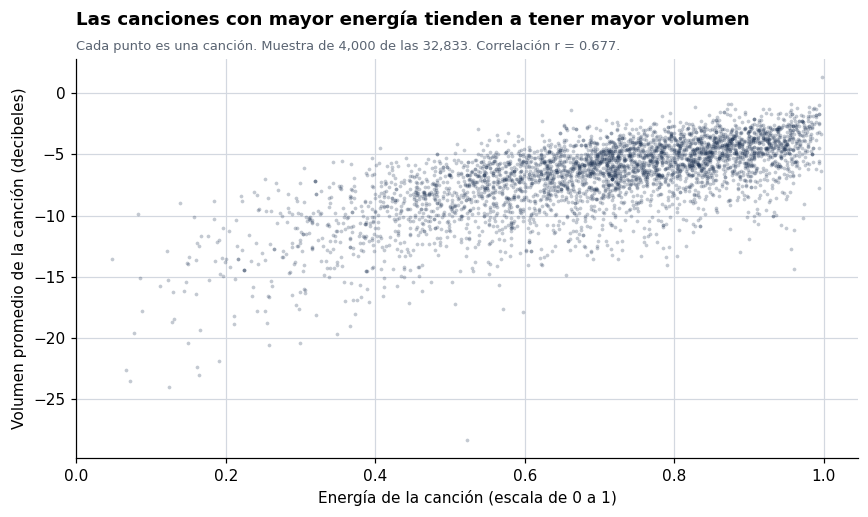

r = 0.6766   ->   r al cuadrado = 0.4578  (45.8% de la variacion compartida)
Muestra graficada: 4,000 canciones de 32,833 (random_state=1).

CORRELACION DE CADA VARIABLE DE AUDIO CON track_popularity
instrumentalness   -0.1499
duration_min       -0.1437
energy             -0.1091
liveness           -0.0546
tempo              -0.0054
speechiness         0.0068
valence             0.0332
loudness            0.0577
danceability        0.0647
acousticness        0.0852

La mas relacionada con la popularidad (en valor absoluto): instrumentalness  r = -0.1499
Aun esa explica solo el 2.2% de la variacion de la popularidad.


In [5]:
# a) Matriz de correlacion
corr = df[audio].corr()
print("MATRIZ DE CORRELACION DE LAS 10 VARIABLES DE AUDIO")
display(corr.round(3))

# b) Lista de pares ordenada: el mas positivo y el mas negativo
pares = corr.unstack()
pares = pares[pares < 0.999]                                                        # fuera la diagonal
pares = pares[pares.index.get_level_values(0) < pares.index.get_level_values(1)]    # fuera los repetidos
pares = pares.sort_values()

print(f"\nNumero de pares unicos: {len(pares)}   (deben ser 45)")

par_neg, r_neg = pares.index[0],  pares.iloc[0]
par_pos, r_pos = pares.index[-1], pares.iloc[-1]

print(f"\nPar MAS NEGATIVO : {par_neg[0]} vs {par_neg[1]}   r = {r_neg:.4f}")
print(f"Par MAS POSITIVO : {par_pos[0]} vs {par_pos[1]}   r = {r_pos:.4f}")

print("\nLos 5 pares mas negativos:")
print(pares.head(5).round(4).to_string())
print("\nLos 5 pares mas positivos:")
print(pares.tail(5).round(4).to_string())

# c) Diagrama de dispersion del par mas positivo
x_var, y_var = par_pos
m = df.sample(4000, random_state=1)

plt.figure(figsize=(8, 4.8))
plt.scatter(m[x_var], m[y_var], s=6, alpha=0.25, color=AZUL, lw=0)
plt.xlabel("Energía de la canción (escala de 0 a 1)")
plt.ylabel("Volumen promedio de la canción (decibeles)")
ax = plt.gca()
ax.set_title("Las canciones con mayor energía tienden a tener mayor volumen",
             fontsize=12, fontweight="bold", loc="left", pad=22)
ax.text(0, 1.015,
        f"Cada punto es una canción. Muestra de 4,000 de las 32,833. Correlación r = {r_pos:.3f}.",
        transform=ax.transAxes, fontsize=8.5, color="#5A6472", va="bottom")
plt.tight_layout()
plt.show()

print(f"r = {r_pos:.4f}   ->   r al cuadrado = {r_pos**2:.4f}  "
      f"({r_pos**2*100:.1f}% de la variacion compartida)")
print("Muestra graficada: 4,000 canciones de 32,833 (random_state=1).")

# d) Correlacion de cada variable de audio con track_popularity
corr_pop = (df[audio + ["track_popularity"]].corr()["track_popularity"]
              .drop("track_popularity")
              .sort_values())
print("\nCORRELACION DE CADA VARIABLE DE AUDIO CON track_popularity")
print(corr_pop.round(4).to_string())

mas_fuerte = corr_pop.abs().idxmax()
print(f"\nLa mas relacionada con la popularidad (en valor absoluto): "
      f"{mas_fuerte}  r = {corr_pop[mas_fuerte]:.4f}")
print(f"Aun esa explica solo el {corr_pop[mas_fuerte]**2*100:.1f}% de la variacion de la popularidad.")

### 📝 Tu respuesta — Ejercicio 4

**1.** ¿Cuál es el par con la correlación **positiva** más fuerte y cuál con la **negativa** más
   fuerte? Da los dos valores de r.

El par con la correlación positiva más fuerte es **`energy` y `loudness`, con r = 0.677**. El par con la
correlación negativa más fuerte es **`acousticness` y `energy`, con r = −0.540**.

El resto de los pares presenta correlaciones mucho más bajas. El tercer valor más alto en magnitud es
`acousticness` con `loudness` (r = −0.362), y la mayoría de los 45 pares se mantiene por debajo de
0.20 en valor absoluto.

**2.** Mira tu diagrama de dispersión. La correlación es alta, pero la nube **no** es una línea.
   ¿Qué te dice eso sobre lo que r puede y no puede predecir para **una** canción concreta?

La correlación de 0.677 describe una tendencia general del conjunto de datos. Para una canción
individual, su capacidad de predicción es limitada.

Si elevo r al cuadrado obtengo 0.458, lo que significa que aproximadamente el **46%** de la variación del
volumen se relaciona con la energía. El 54% restante depende de factores que ese número no incluye,
como el género, el año de la grabación o las decisiones de mezcla y masterización.

En el gráfico se observa que, para un valor de `energy` cercano a 0.8, hay canciones con volúmenes
que van desde aproximadamente −12 dB hasta cerca de 0 dB. El promedio para ese nivel de energía es
−5.6 dB, pero el rango real de valores es amplio. Por eso la correlación sirve para describir el
comportamiento del conjunto y resulta poco confiable al aplicarla a un caso particular.

**3.** Escribe **una frase de veredicto** sobre el par más positivo: ¿se puede afirmar que una
   variable **causa** a la otra? Antes de responder descarta las tres alternativas que vimos en
   clase: una **variable oculta** que mueva a las dos, la **causa invertida**, o la **coincidencia**.

**No se puede afirmar que una variable cause a la otra.**

La coincidencia queda descartada. Con 32,833 canciones, una correlación de 0.677 es demasiado alta
para atribuirla al azar.

La causa invertida sigue siendo posible. Spotify calcula `energy` combinando varias características
del sonido, y una de ellas es el volumen percibido. Bajo esa definición resulta más razonable decir
que el volumen influye en el cálculo de `energy`.

La variable oculta también sigue siendo posible. El estilo de producción de cada género afecta ambas
variables al mismo tiempo: las canciones de EDM se producen con instrumentación densa y se masterizan
a volumen alto, mientras que las baladas acústicas se graban con menos instrumentos y a volumen bajo.
En ese caso sería el género el que mueve las dos variables de forma simultánea.

Como dos de las tres alternativas siguen siendo posibles, la conclusión es que ambas variables se
mueven juntas y que haría falta un diseño experimental para establecer una relación de causa.

**4.** De las 10 variables de audio, ¿cuál correlaciona más con `track_popularity`? ¿Es una
   relación fuerte o débil? ¿Te sirve ese número solo para predecir si una canción será popular?

La variable que más se relaciona con `track_popularity` es **`instrumentalness`, con r = −0.150**. Le
siguen `duration_min` (−0.144) y `energy` (−0.109).

Es una relación débil. Al elevar −0.150 al cuadrado obtengo 0.022, lo que significa que
`instrumentalness` explica aproximadamente el **2.2%** de la variación de la popularidad. Ninguna de las
otras nueve variables supera 0.15 en valor absoluto.

Ese número por sí solo no sirve para predecir si una canción será popular. El resultado sugiere que
la popularidad depende principalmente de factores que no están en esta tabla, como la inclusión de la
canción en playlists, el reconocimiento del artista, la promoción o el funcionamiento del algoritmo
de recomendación. También conviene señalar que `energy` presenta signo negativo con la popularidad
(−0.109), lo que contradice la idea de que una mayor energía aumenta la popularidad.

---
# Ejercicio 5 · La relación escondida
**Dificultad: media** · 25 puntos

En el Ejercicio 4 calculaste correlaciones sobre **toda la tabla**. Pero en el Ejercicio 3
comprobaste que los géneros son muy distintos entre sí. La pregunta final del problem set es qué
pasa cuando juntas las dos cosas.

Trabaja con el par **`energy` y `danceability`**.

**a)** Calcula la correlación entre `energy` y `danceability` **en el conjunto completo**.

**b)** Calcula **esa misma correlación dentro de cada género**. Arma una tabla con los seis
valores, ordenada, y guárdala en `corr_genero`.

**c)** Junta en una sola tabla, para cada género: la **media de energy** (la tienes en
`energia_genero`, del Ejercicio 3), la **media de `danceability`**, la **media de
`track_popularity`** y la **correlación** de (b).

**d)** Estandariza `energy` creando la columna `energy_z`, y encuentra la canción con el
**z más alto**. Muestra su nombre, artista, género, `energy` y `energy_z`.
Comprueba además que `energy_z` tiene media 0 y desviación 1, y que su `skew()` es el mismo
que el de `energy` original.

> 💡 **Pistas.**
> Correlación por grupo:
> `df.groupby("playlist_genre").apply(lambda g: g["energy"].corr(g["danceability"])).sort_values()`
> El `lambda g:` recibe el sub-DataFrame de cada género.
> Para juntar tablas que comparten el mismo índice (el género): `pd.concat([tabla1, tabla2], axis=1)`.
> Estandarización: `z = (x - x.mean()) / x.std()`.
> `.idxmax()` devuelve el **índice** de la fila con el valor máximo; con `df.loc[idx, [...]]`
> sacas las columnas que quieras de esa fila.
>
> ⚠️ Antes de escribir la conclusión, mira los **signos** de la tabla de (b): ¿todos los géneros
> apuntan hacia el mismo lado?

a) Correlacion GLOBAL entre energy y danceability: r = -0.0861
   (practicamente cero: pareceria que no hay ninguna relacion)

b) LA MISMA CORRELACION, DENTRO DE CADA GENERO
playlist_genre
rock    -0.1529
edm     -0.1503
rap     -0.1482
pop     -0.0307
latin    0.1159
r&b      0.1592

   Generos con signo NEGATIVO: 4 de 6
   Generos con signo POSITIVO: 2 de 6
   -> Los signos NO apuntan todos hacia el mismo lado: se cancelan en el promedio global.

c) TABLA RESUMEN POR GENERO


,energy_media,energy_desv,danceability_media,popularidad_media,r_energy_vs_dance
playlist_genre,,,,,
edm,0.8025,0.1394,0.6550,34.8335,-0.1503
rock,0.7328,0.1945,0.5205,41.7283,-0.1529
latin,0.7083,0.1523,0.7133,47.0266,0.1159
pop,0.7010,0.1711,0.6393,47.7449,-0.0307
rap,0.6507,0.1703,0.7184,43.2155,-0.1482
r&b,0.5909,0.1794,0.6702,41.2235,0.1592


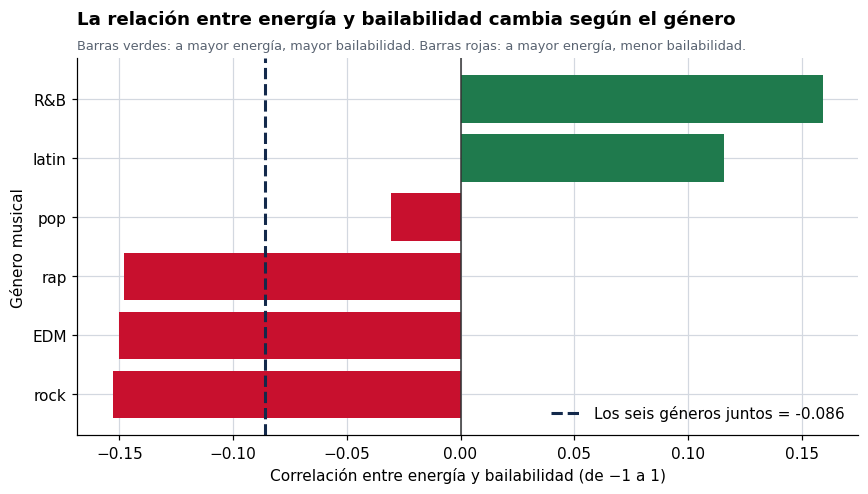


d) CANCION CON EL energy_z MAS ALTO
track_name        Rain Forest and Tropical Beach Sound
track_artist                Nature Sounds Nature Music
playlist_genre                                   latin
energy                                             1.0
energy_z                                      1.665915

   Comprobaciones de la estandarizacion:
   media  de energy_z : -2.35e-16   (debe ser 0)
   desv.  de energy_z : 1.000000   (debe ser 1)
   skew   de energy   : -0.636330
   skew   de energy_z : -0.636330   (identico: es la misma forma)

   Canciones que tocan el techo energy = 1.000 : 3
   z maximo posible con este techo             : 1.6659


In [6]:
# a) Correlacion global entre energy y danceability
r_global = df["energy"].corr(df["danceability"])
print(f"a) Correlacion GLOBAL entre energy y danceability: r = {r_global:.4f}")
print("   (practicamente cero: pareceria que no hay ninguna relacion)")

# b) La misma correlacion dentro de cada genero
corr_genero = (df.groupby("playlist_genre")[["energy", "danceability"]]
                 .apply(lambda g: g["energy"].corr(g["danceability"]))
                 .sort_values())
corr_genero.name = "r_energy_danceability"
print("\nb) LA MISMA CORRELACION, DENTRO DE CADA GENERO")
print(corr_genero.round(4).to_string())
print(f"\n   Generos con signo NEGATIVO: {(corr_genero < 0).sum()} de 6")
print(f"   Generos con signo POSITIVO: {(corr_genero > 0).sum()} de 6")
print("   -> Los signos NO apuntan todos hacia el mismo lado: se cancelan en el promedio global.")

# c) Tabla resumen por genero
resumen = pd.concat([
    energia_genero["mean"].rename("energy_media"),
    energia_genero["std"].rename("energy_desv"),
    df.groupby("playlist_genre")["danceability"].mean().rename("danceability_media"),
    df.groupby("playlist_genre")["track_popularity"].mean().rename("popularidad_media"),
    corr_genero.rename("r_energy_vs_dance"),
], axis=1).sort_values("energy_media", ascending=False)

print("\nc) TABLA RESUMEN POR GENERO")
display(resumen.round(4))

plt.figure(figsize=(8, 4.6))
colores = ["#C8102E" if v < 0 else "#1F7A4D" for v in corr_genero.values]
plt.barh([NOMBRES[g] for g in corr_genero.index], corr_genero.values, color=colores)
plt.axvline(0, color="#333333", lw=1)
plt.axvline(r_global, color=AZUL, lw=2, ls="--",
            label=f"Los seis géneros juntos = {r_global:.3f}")
plt.xlabel("Correlación entre energía y bailabilidad (de −1 a 1)")
plt.ylabel("Género musical")
ax = plt.gca()
ax.set_title("La relación entre energía y bailabilidad cambia según el género",
             fontsize=12, fontweight="bold", loc="left", pad=22)
ax.text(0, 1.015,
        "Barras verdes: a mayor energía, mayor bailabilidad. Barras rojas: a mayor energía, menor bailabilidad.",
        transform=ax.transAxes, fontsize=8.5, color="#5A6472", va="bottom")
plt.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

# d) Estandarizacion de energy y cancion mas extrema
df["energy_z"] = (df["energy"] - df["energy"].mean()) / df["energy"].std()

idx = df["energy_z"].idxmax()
print("\nd) CANCION CON EL energy_z MAS ALTO")
print(df.loc[idx, ["track_name", "track_artist", "playlist_genre", "energy", "energy_z"]].to_string())

print("\n   Comprobaciones de la estandarizacion:")
print(f"   media  de energy_z : {df['energy_z'].mean():.2e}   (debe ser 0)")
print(f"   desv.  de energy_z : {df['energy_z'].std():.6f}   (debe ser 1)")
print(f"   skew   de energy   : {df['energy'].skew():.6f}")
print(f"   skew   de energy_z : {df['energy_z'].skew():.6f}   (identico: es la misma forma)")
print(f"\n   Canciones que tocan el techo energy = 1.000 : {(df['energy'] == 1.0).sum()}")
print(f"   z maximo posible con este techo             : "
      f"{(1.0 - df['energy'].mean()) / df['energy'].std():.4f}")

### 📝 Tu respuesta — Ejercicio 5

**1.** ¿Cuánto vale r en el conjunto completo? ¿Cuál es el género con el r **más negativo** y
   cuál con el **más positivo**? Da los tres números.

En el conjunto completo, **r = −0.086**. El género con el valor más negativo es **rock, con r = −0.153**, y
el más positivo es **R&B, con r = 0.159**.

Los demás géneros se distribuyen entre esos dos valores: EDM (−0.150) y rap (−0.148) del lado
negativo, latin (0.116) del lado positivo, y pop en una posición intermedia con −0.031.

**2.** Si el r global es cercano a cero, ¿se puede concluir que `energy` y `danceability`
   no tienen ninguna relación? Explica qué está pasando por debajo del promedio global.
   ¿Cuál es la "tercera variable" de la que hablamos en la lámina de correlación y causalidad?

**No se puede concluir que no exista relación entre `energy` y `danceability`.** El valor global cercano
a cero se produce porque los géneros tienen correlaciones de signo contrario que se cancelan al
calcular el promedio general.

Dentro de rock, EDM y rap, un aumento en la energía se asocia con una menor bailabilidad. Dentro de
R&B y latin ocurre lo contrario: la energía y la bailabilidad aumentan juntas, ya que en esos géneros
la energía está más ligada al ritmo. Al combinar los seis géneros en un solo cálculo, el −0.153 de
rock y el 0.159 de R&B se anulan entre sí, y el resultado final de −0.086 no describe el comportamiento
de ningún género en particular.

**La tercera variable es el género musical.** Está relacionada con las dos variables analizadas al mismo
tiempo y, al dejarla fuera del cálculo, el resultado global distorsiona la relación real. Corresponde a la **paradoja de Simpson**, en la que una tendencia presente dentro de cada subgrupo desaparece o se
invierte al agregar los subgrupos.

**3.** Mira la tabla de (c) junto con lo que sacaste en el Ejercicio 4(d). ¿El género con la
   energía media más alta es también el más popular? ¿Qué le dirías a la plataforma de streaming
   si te pidiera "subirle la energía a las canciones para que sean más populares"?

**No.** El género con la energía media más alta es **EDM (0.802)** y es el menos popular de los seis, con una popularidad media de **34.8**. El más popular es **pop, con 47.7** y una energía de 0.701, seguido de latin
con 47.0 y una energía de 0.708. Rock, que es el segundo más enérgico (0.733), tiene una popularidad
media de 41.7.

Si la plataforma pidiera subir la energía de las canciones para aumentar su popularidad, le indicaría
que los datos no respaldan esa estrategia. La correlación entre `energy` y `track_popularity`
calculada en el Ejercicio 4(d) es −0.109, un valor débil y de signo negativo. La comparación entre
géneros muestra lo mismo: el género con mayor energía es el que registra menor popularidad. Además,
ninguna de las diez variables de audio supera 0.15 de correlación con la popularidad, por lo que en
conjunto explican una proporción muy pequeña del resultado.

Cabe aclarar que estos datos tampoco permiten identificar qué sí determina la popularidad, ya que
factores como la promoción o la inclusión en playlists no están en la tabla. Si aun así quisieran
hacer pruebas con las características de audio, tendrían que realizarlas dentro de cada género por
separado, porque las relaciones entre variables cambian de signo según el género.

**4.** La canción con el `energy_z` más alto: ¿qué tan lejos de la media está, en desviaciones
   estándar? ¿Por qué el `skew()` de `energy_z` es idéntico al de `energy`, si le restamos la
   media y la dividimos entre la desviación?

La canción con el `energy_z` más alto está a **1.67 desviaciones estándar** por encima de la media. Su
valor de `energy` es 1.000, que corresponde al máximo de la escala, por lo que 1.67 es también el
valor máximo que puede alcanzar `energy_z` en este conjunto de datos. Hay 3 canciones con `energy`
igual a 1.000 y `.idxmax()` devuelve la primera de ellas.

La canción es "Rain Forest and Tropical Beach Sound", del artista Nature Sounds Nature Music,
clasificada como latin. Se trata de una grabación de sonidos ambientales, lo que indica que el índice
de `energy` puede asignar valores altos a audios que no corresponden a canciones. La clasificación de
género también parece incorrecta.

El `skew()` de `energy_z` es idéntico al de `energy` (**−0.6363**) porque la estandarización solo
desplaza y reescala la distribución. Restar la media cambia la posición de los datos y dividir entre
la desviación estándar cambia su escala, pero ninguna de las dos operaciones altera el orden de los
valores ni la proporción entre las distancias. Como el `skew()` mide la forma de la distribución, el
resultado se mantiene igual.

Lo que sí cambia son la media, que pasa de 0.699 a 0, y la desviación estándar, que pasa de 0.181 a 1.
Ese es el propósito de estandarizar: llevar variables con unidades distintas a una escala común para
poder compararlas, como ocurre con un índice de 0 a 1, los decibeles y los pulsos por minuto.

---
# Cierre · El entregable escrito

Escribe **un párrafo de 4 a 6 frases** dirigido a alguien que **no tomó este curso** —el gerente
de producto de la plataforma de streaming— con el hallazgo principal del problem set.

Requisitos:

1. Empieza por el **hallazgo**, no por el método.
2. Usa **al menos tres números** de los que calculaste, indicando de qué ejercicio salen.
3. **Sin jerga**: nada de "r", "desviación estándar" ni "skew" sin traducir a español común.
4. Cierra con **una advertencia**: algo que estos datos **NO** permiten concluir.

> 💡 "r = 0.06" no es una frase. "En el conjunto completo parece que no hay relación, pero es
> porque dos géneros se comportan al revés y se cancelan entre sí" sí lo es.

### 📝 Tu párrafo

El análisis muestra que aumentar la intensidad de las canciones no las vuelve más populares: el
género más intenso del catálogo, el EDM, es el menos escuchado de los seis, con **34.8** puntos de popularidad promedio frente a los **47.7** del pop (Ejercicio 5). De las diez características de sonido
que medimos, ninguna alcanza siquiera un **3%** de influencia sobre la popularidad de una canción
(Ejercicio 4), lo que indica que el factor decisivo está fuera del sonido. Donde sí hay diferencias
claras entre géneros es en qué tan parecidas son sus canciones entre sí: el EDM se mantiene en **0.80 sobre 1** de forma bastante uniforme, mientras que el rock promedia **0.73** e incluye tanto baladas suaves
como temas muy intensos (Ejercicio 3). También encontramos que, al mirar el catálogo completo, la
intensidad y lo bailable parecían no tener relación, y al separar por género vimos que en rock y EDM
se mueven en direcciones opuestas mientras en R&B y latin se mueven juntas, de modo que las dos
tendencias se cancelan al sumarlas (Ejercicio 5). Como advertencia, estos datos describen las
canciones que ya existen y cuánto se escuchan actualmente, por lo que no permiten anticipar qué haría
exitosa a una canción nueva: eso depende de en qué playlists se incluya, de quién la interprete y de
cuánta promoción reciba, y nada de eso está en la tabla.


---

### 🤖 Uso de IA

¿En qué ejercicios usaste IA? Para cada uno, explica **qué hace ese código** o **qué alternativa
pensaste antes de preguntar**.

Usé inteligencia artificial en tres puntos del cuaderno, todos relacionados con la parte técnica del
código.

**Ejercicio 4(b), para armar la lista de pares a partir de la matriz de correlación.** El método
`unstack()` convierte la matriz de 10×10 en una lista de 100 filas, donde cada fila corresponde a una
pareja de variables con su valor de correlación. De esa lista hay que eliminar dos cosas: la
diagonal, que son los casos en que una variable se compara consigo misma y siempre da 1, y los pares
repetidos, ya que la matriz es simétrica y cada pareja aparece dos veces. La diagonal la elimino
filtrando los valores menores a 0.999 y los repetidos los elimino comparando los nombres de las dos
variables en orden alfabético, de manera que solo quede una versión de cada pareja. El resultado son
45 pares, que corresponde a la cantidad de combinaciones posibles entre 10 variables. Antes de
consultar había considerado recorrer la matriz con dos ciclos `for` anidados, tomando únicamente la
parte superior; el resultado sería el mismo, aunque requiere más líneas de código.

**Ejercicio 5(b), para entender el uso de `lambda` dentro de `apply()`.** El método
`groupby("playlist_genre")` divide la tabla en seis subconjuntos, uno por género, y `apply()` envía
cada subconjunto completo a la función. Dentro de la función, `g` representa la tabla de ese género,
por lo que `g["energy"].corr(g["danceability"])` calcula la correlación usando solo las canciones de
ese género. La alternativa que había pensado era recorrer los géneros con un ciclo, filtrar la tabla
en cada iteración con `df[df["playlist_genre"] == g]` y guardar los resultados en un diccionario.

**Presentación de los gráficos.** Consulté cómo agregar el valor numérico al final de cada barra con
`plt.text()`, cómo asignar color a las barras del Ejercicio 5 según el signo de la correlación y cómo
dar color a las cajas del boxplot con `patch_artist=True`. Estos ajustes son de formato y no
modifican ningún resultado.

Los cálculos de los Ejercicios 1, 2 y 3, la estandarización del Ejercicio 5(d), la interpretación de
los resultados y las respuestas escritas los realicé por mi cuenta.


---

### ✅ Antes de entregar, verifica:

- [x] Kernel → Restart & Run All: el cuaderno corre de principio a fin **sin errores**.
- [x] Todos los gráficos tienen **título** y **etiquetas de eje con unidad**.
- [x] Todas las celdas de *Tu respuesta* están contestadas.
- [ ] El cuaderno está en **GitHub** con el nombre `S100_PS1_Correa.ipynb`.
- [ ] Envié el **enlace** (y solo el enlace) a gabriel.soto@utp.ac.pa.
- [ ] Agregué el enlace en `S100 Lista Estudiantes Provisional`, carpeta `01_administracion`
      del SharePoint, junto a mi nombre.